In [9]:
import pandas as pd
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from textblob import TextBlob
import matplotlib.pyplot as plt


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [2]:
df = pd.read_csv("/content/hotel_reviews.csv")

In [4]:
print(df[["Review"]].head())

                                              Review
0  nice hotel expensive parking got good deal sta...
1  ok nothing special charge diamond member hilto...
2  nice rooms not 4* experience hotel monaco seat...
3  unique, great stay, wonderful time hotel monac...
4  great stay great stay, went seahawk game aweso...


In [5]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

def preprocess(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()   # No NLTK tokenizer needed

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)
df["Clean_Review"] = df["Review"].apply(preprocess)

In [7]:
def sentiment(review):
    score = TextBlob(review).sentiment.polarity

    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment"] = df["Clean_Review"].apply(sentiment)

In [8]:
issues = {
    "Room": ["room", "bed", "bathroom", "clean"],
    "Staff": ["staff", "manager", "reception", "service"],
    "Food": ["food", "breakfast", "dinner", "restaurant"],
    "Amenities": ["wifi", "pool", "gym", "parking", "spa"]
}

def identify_issue(review):
    found = []
    review = review.lower()

    for category, keywords in issues.items():
        if any(word in review for word in keywords):
            found.append(category)

    return ", ".join(found) if found else "Other"

df["Issue_Category"] = df["Review"].apply(identify_issue)

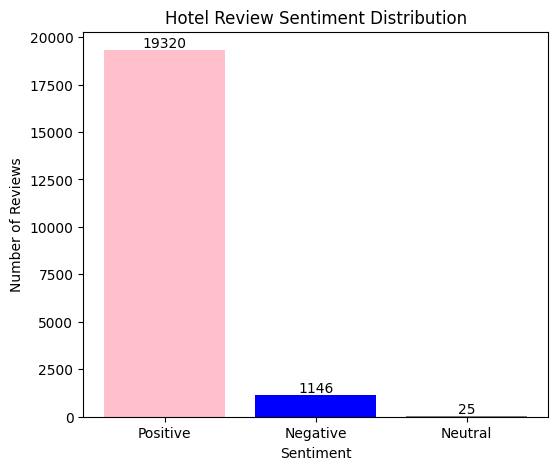

In [13]:
sentiment_counts = df["Sentiment"].value_counts()
plt.figure(figsize=(6,5))
colors = ['pink', 'blue', 'gray'] # Define colors for Positive, Negative, Neutral
plt.bar(sentiment_counts.index, sentiment_counts.values, color=colors)
plt.title("Hotel Review Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
for i, value in enumerate(sentiment_counts.values):
    plt.text(i, value, str(value), ha='center', va='bottom')

plt.show()